# 02 · PTO vs GRPO (Exp3) — *the core method comparison*

Research question (ii): under **matched look-ahead K**, is iterative GRPO competitive with PTO?
Matched-iteration paired contrast → paired PTO−GRPO statistics → **training internals side-by-side**
(PTO chosen−rejected margin **and** GRPO group_std, never gated) → per-iteration climb-rate. Absorbs
the old `Exp3_DeepDive`.

In [1]:
import sys, os; sys.path.insert(0, os.path.abspath("."))           # cwd = eda/ -> `import exp3`
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
pd.set_option("display.width", 185, "display.max_columns", 50)
import exp3
from exp3 import stats, behavior, training, pref, figures, plots
S = exp3.notebook_setup()      # S.ARMS, S.SCORES, S.PALETTE, S.METRICS, S.ORACLE_NOISE, S.RESULTS_DIR

arms on disk: [('PTO_LA0', 11), ('PTO_LA5', 6), ('GRPO_LA0', 6), ('GRPO_LA5', 2)]
scores_long: (16128, 19) | arms scored: ['GRPO_LA0', 'GRPO_LA5', 'PTO_LA0', 'PTO_LA5']
exports -> C:\Users\baruc\Desktop\Projects\Thesis_PTO_GRPO\Exp3_PTO_GRPO\eda\results


## 1 · Matched-K outcome contrast (PTO vs GRPO trajectories)

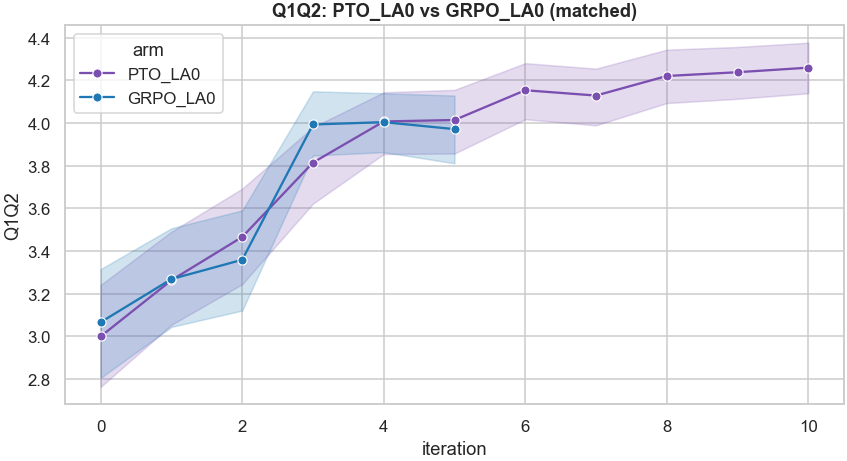

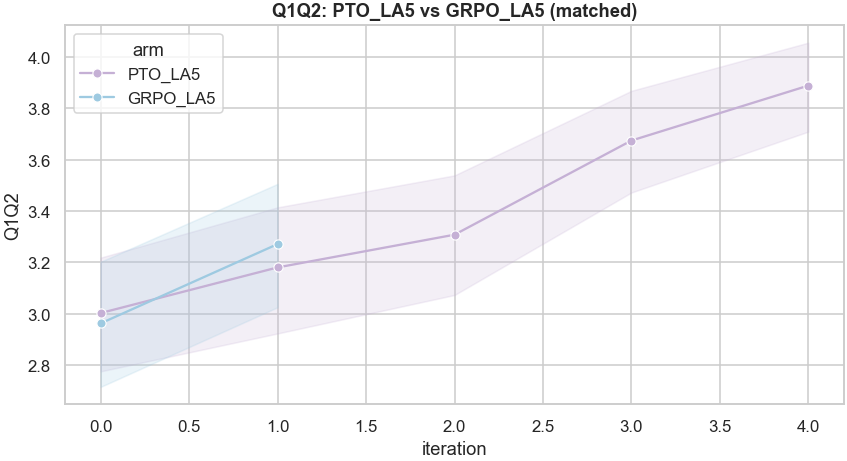

In [2]:
for K in sorted(S.SCORES.K.unique()):
    fig = plots.method_contrast_overlay(S.SCORES, "Q1Q2", pair=(f"PTO_LA{K}", f"GRPO_LA{K}"), palette=S.PALETTE)
    if fig is None:
        print(f"K={K}: no overlapping PTO/GRPO arms yet."); continue
    exp3.save_fig(fig, f"method_contrast_Q1Q2_LA{K}", caption=f"PTO vs GRPO Q1+Q2 trajectories at matched look-ahead K={K} (mean +/- 95% CI).")
    plt.show()

## 2 · Paired PTO − GRPO statistics at matched iterations

In [3]:
for K in sorted(S.SCORES.K.unique()):
    CMP = stats.paired_method_comparison(S.SCORES, "PTO", "GRPO", K=K)
    if CMP.empty:
        print(f"K={K}: no common PTO/GRPO scored iterations yet."); continue
    view = CMP[["iteration", "metric", "n", "mean_delta", "dz", "p_holm"]].round(4)
    print(f"\n=== PTO_LA{K} - GRPO_LA{K} (paired; + => PTO higher) ==="); display(view)
    exp3.save_table(view, f"PTO_vs_GRPO_LA{K}_paired",
                    caption=f"PTO_LA{K} - GRPO_LA{K} at matched iterations; persona-paired Wilcoxon + dz + Holm.")


=== PTO_LA0 - GRPO_LA0 (paired; + => PTO higher) ===


,iteration,metric,n,mean_delta,dz,p_holm
0,0,Q1Q2,96,-0.0664,-0.0688,1.0000
1,0,WAI-SR,96,-0.0451,-0.0675,1.0000
2,0,CSQ-8,96,0.0221,0.0316,1.0000
3,0,MI-SAT,96,-0.0191,-0.0213,1.0000
4,0,MITI,96,-0.0911,-0.1021,1.0000
5,0,Q1,96,-0.0979,-0.0976,1.0000
6,0,Q2,96,-0.0349,-0.0354,1.0000
7,1,Q1Q2,96,-0.0055,-0.0060,1.0000
8,1,WAI-SR,96,-0.0807,-0.1129,1.0000
9,1,CSQ-8,96,-0.0755,-0.1153,1.0000



=== PTO_LA5 - GRPO_LA5 (paired; + => PTO higher) ===


,iteration,metric,n,mean_delta,dz,p_holm
0,0,Q1Q2,96,0.0401,0.0415,1.0
1,0,WAI-SR,96,-0.0373,-0.0570,1.0
2,0,CSQ-8,96,-0.0169,-0.0277,1.0
3,0,MI-SAT,96,0.0017,0.0023,1.0
4,0,MITI,96,0.0286,0.0355,1.0
5,0,Q1,96,0.0354,0.0356,1.0
6,0,Q2,96,0.0447,0.0448,1.0
7,1,Q1Q2,96,-0.0907,-0.0945,1.0
8,1,WAI-SR,96,-0.0391,-0.0550,1.0
9,1,CSQ-8,96,0.0156,0.0201,1.0


## 3 · Training internals — side-by-side (both methods)
The symmetric replacement for the gated DeepDive cell: per-candidate reward distribution per arm, and
the method-native advantage signal (GRPO `group_std` vs PTO chosen−rejected `margin`) in one figure.

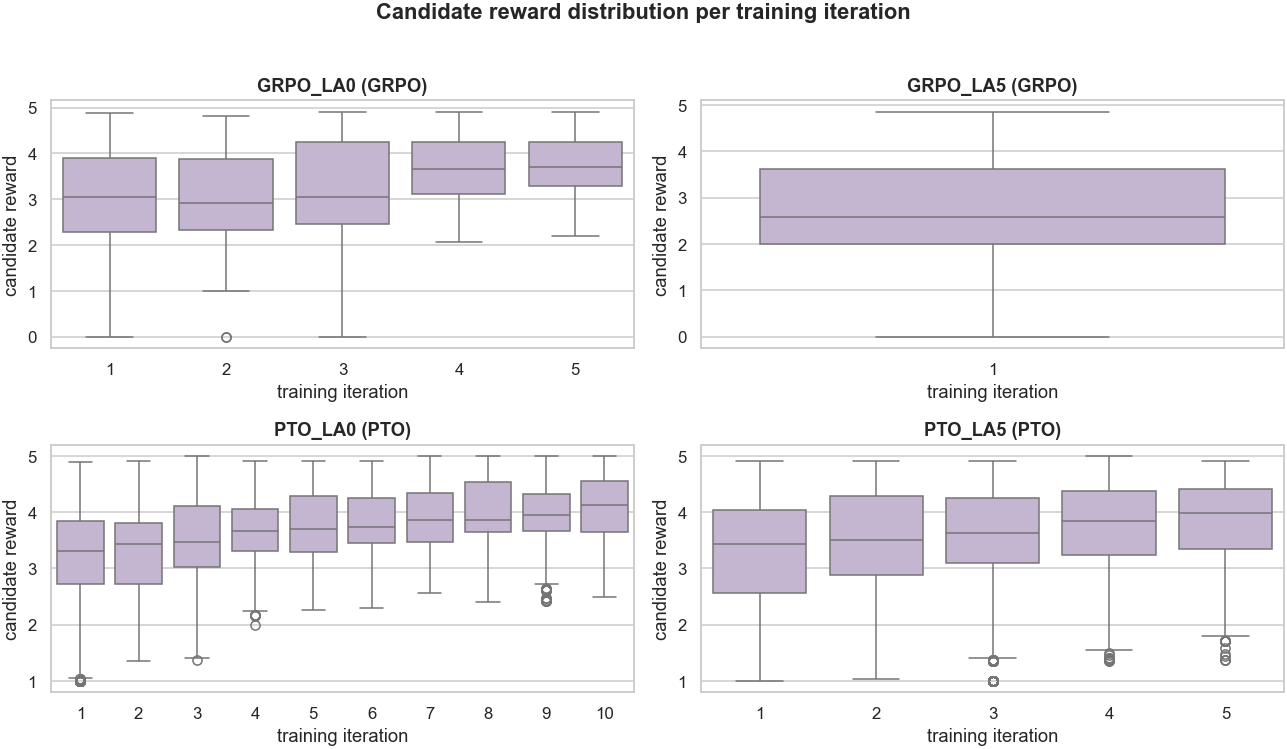

,arm,method,train_iter,group_std,frac_zero_std,margin,margin_median,n_pairs
0,GRPO_LA0,GRPO,1,0.1265,0.0379,NaN,NaN,NaN
1,GRPO_LA0,GRPO,2,0.1177,0.0299,NaN,NaN,NaN
2,GRPO_LA0,GRPO,3,0.1018,0.0185,NaN,NaN,NaN
3,GRPO_LA0,GRPO,4,0.0821,0.0387,NaN,NaN,NaN
4,GRPO_LA0,GRPO,5,0.0823,0.0518,NaN,NaN,NaN
5,GRPO_LA5,GRPO,1,0.1771,0.0201,NaN,NaN,NaN
6,PTO_LA0,PTO,1,NaN,NaN,0.3217,0.2765,782.0
7,PTO_LA0,PTO,2,NaN,NaN,0.2988,0.2588,618.0
8,PTO_LA0,PTO,3,NaN,NaN,0.2946,0.2588,620.0
9,PTO_LA0,PTO,4,NaN,NaN,0.2690,0.2353,536.0


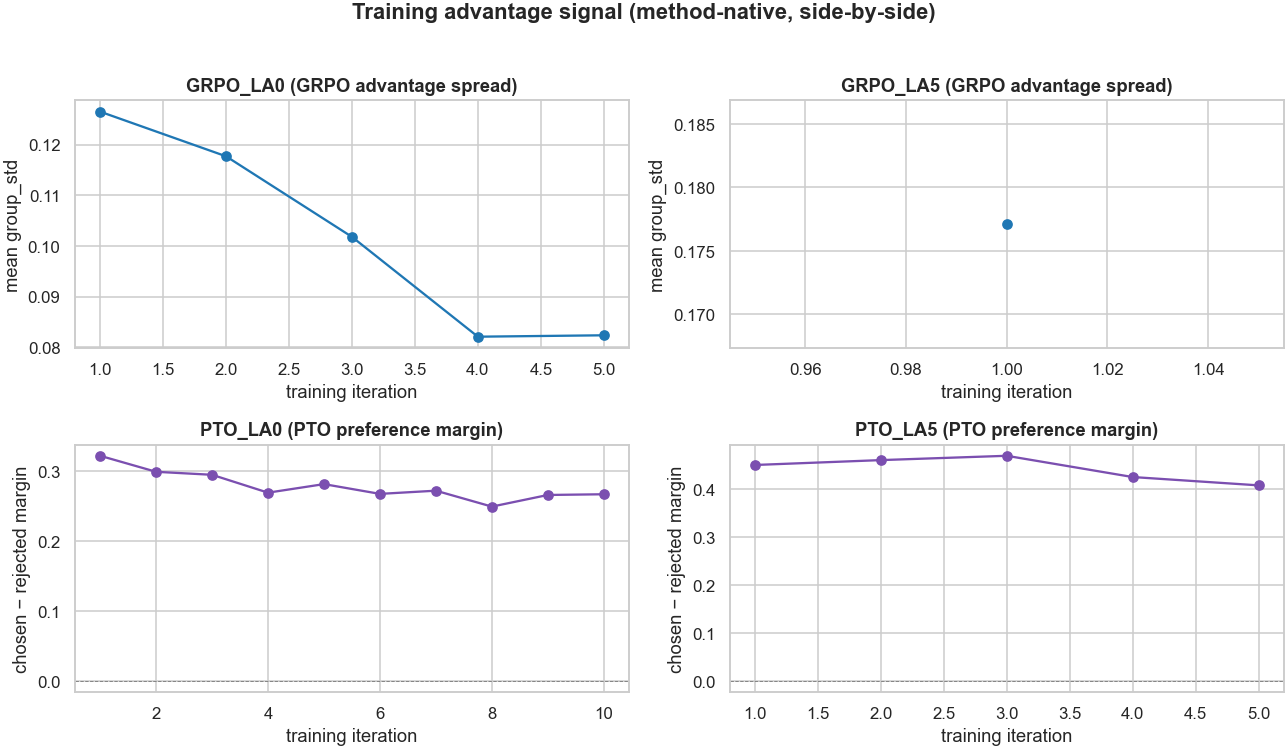

In [4]:
RWD = training.reward_distribution_frame(S.ARMS)
fig = plots.reward_distribution(RWD)
if fig: exp3.save_fig(fig, "reward_distribution_by_arm", caption="Per-candidate training reward per iteration, one panel per arm (PTO + GRPO)."); plt.show()
ADV = training.advantage_signal_by_iter(S.ARMS); display(ADV.round(4))
fig = plots.advantage_signal_sidebyside(ADV)
if fig: exp3.save_fig(fig, "advantage_signal_sidebyside", caption="Method-native training advantage signal: GRPO mean group_std vs PTO chosen-rejected margin, per iteration."); plt.show()

## 4 · Per-iteration climb rate (slope)

In [5]:
SL = pd.DataFrame([stats.trajectory_test(S.SCORES, a, "Q1Q2") for a in sorted(S.SCORES.arm.unique())])
view = SL[["arm", "metric", "spearman_rho", "ols_slope", "peak_iter", "final_iter"]].round(4)
display(view)
exp3.save_table(view, "Q1Q2_slope_by_arm", caption="Q1+Q2 per-iteration OLS slope + Spearman rho per arm (the climb rate).")

,arm,metric,spearman_rho,ols_slope,peak_iter,final_iter
0,GRPO_LA0,Q1Q2,0.3034,0.2104,4.0,5.0
1,GRPO_LA5,Q1Q2,NaN,NaN,NaN,NaN
2,PTO_LA0,Q1Q2,0.3534,0.1203,10.0,10.0
3,PTO_LA5,Q1Q2,0.2720,0.2263,4.0,4.0


'C:\\Users\\baruc\\Desktop\\Projects\\Thesis_PTO_GRPO\\Exp3_PTO_GRPO\\eda\\results\\tables'

## 5 · Takeaways
- **Matched-budget read:** compare PTO_LA0 and GRPO_LA0 at the **same iteration** (§1–2). A higher PTO
  *endpoint* mostly reflects more iterations, not per-iteration superiority — the slope table (§4)
  separates climb-rate from endpoint.
- **Training signal health (§3):** GRPO's `group_std` collapsing toward 0 = vanishing advantages; PTO's
  `margin` shrinking = ties within τ. Watch both for late-iteration saturation.
- _(Whether GRPO hacks the same way PTO does late → behavior drift in `04`.)_